In [2]:
import math
import os
import os.path as osp
import shutil

import cv2
import hdbscan
import matplotlib.pyplot as plt
import numpy as np
import sklearn
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import random
import torch
import torch.nn.functional as F
import umap
from PIL import Image
from tqdm import tqdm
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib
matplotlib.rc("font",family='AR PL UKai CN')


/home/unitx/miniconda3/envs/hjh/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [12]:
npz_path = "../checkpoints/debug/supcon_embeddings.npz"
data = np.load(npz_path)
embeddings = data['embeddings']
labels = data['label_names']
sample_indices = data['sample_indices']

In [13]:
labels = labels.tolist()
unique_labels = list(set(labels))
sorted(unique_labels)

['R角凸起',
 '划伤1',
 '划伤2',
 '压伤',
 '发亮',
 '变形1',
 '变形2',
 '多装1',
 '多装2',
 '开裂',
 '异物1-人造',
 '异物2-黑点',
 '异物3-杂物、灰尘、黑线',
 '异物遮蔽',
 '手指印',
 '折痕',
 '断焊',
 '歪斜1',
 '歪斜2',
 '毛刺',
 '氧化',
 '污渍',
 '溢胶',
 '漏装',
 '焊偏',
 '焊包',
 '焊洞',
 '焊渣',
 '焊烟',
 '焊道划伤',
 '破损',
 '碰伤',
 '磨花1',
 '磨花2',
 '笔迹',
 '缺口',
 '装反1',
 '装反2',
 '装反3',
 '装配错位',
 '起翘1',
 '起翘2',
 '金属丝',
 '错装1',
 '错装2',
 '错装3',
 '间隙大',
 '飞边']

In [14]:
selected_embeddings = []
selected_labels = []
for emb, lb in zip(embeddings, labels):
    # if lb.startswith("capsule"):
    selected_embeddings.append(emb)
    selected_labels.append(lb)

selected_embeddings = np.stack(selected_embeddings)
print(f"selected_embeddings shape: {selected_embeddings.shape}")
print(f"selected_labels: {set(selected_labels)}")

selected_embeddings shape: (10614, 128)
selected_labels: {'磨花2', '氧化', '装反1', '多装1', '碰伤', '金属丝', 'R角凸起', '错装3', '起翘2', '开裂', '装反3', '笔迹', '错装1', '变形1', '焊道划伤', '焊偏', '异物2-黑点', '污渍', '发亮', '变形2', '压伤', '多装2', '焊烟', '歪斜1', '缺口', '焊包', '异物1-人造', '歪斜2', '划伤2', '漏装', '起翘1', '错装2', '装配错位', '焊渣', '折痕', '手指印', '飞边', '断焊', '溢胶', '装反2', '划伤1', '异物遮蔽', '焊洞', '破损', '毛刺', '磨花1', '异物3-杂物、灰尘、黑线', '间隙大'}


Total unique labels: 48


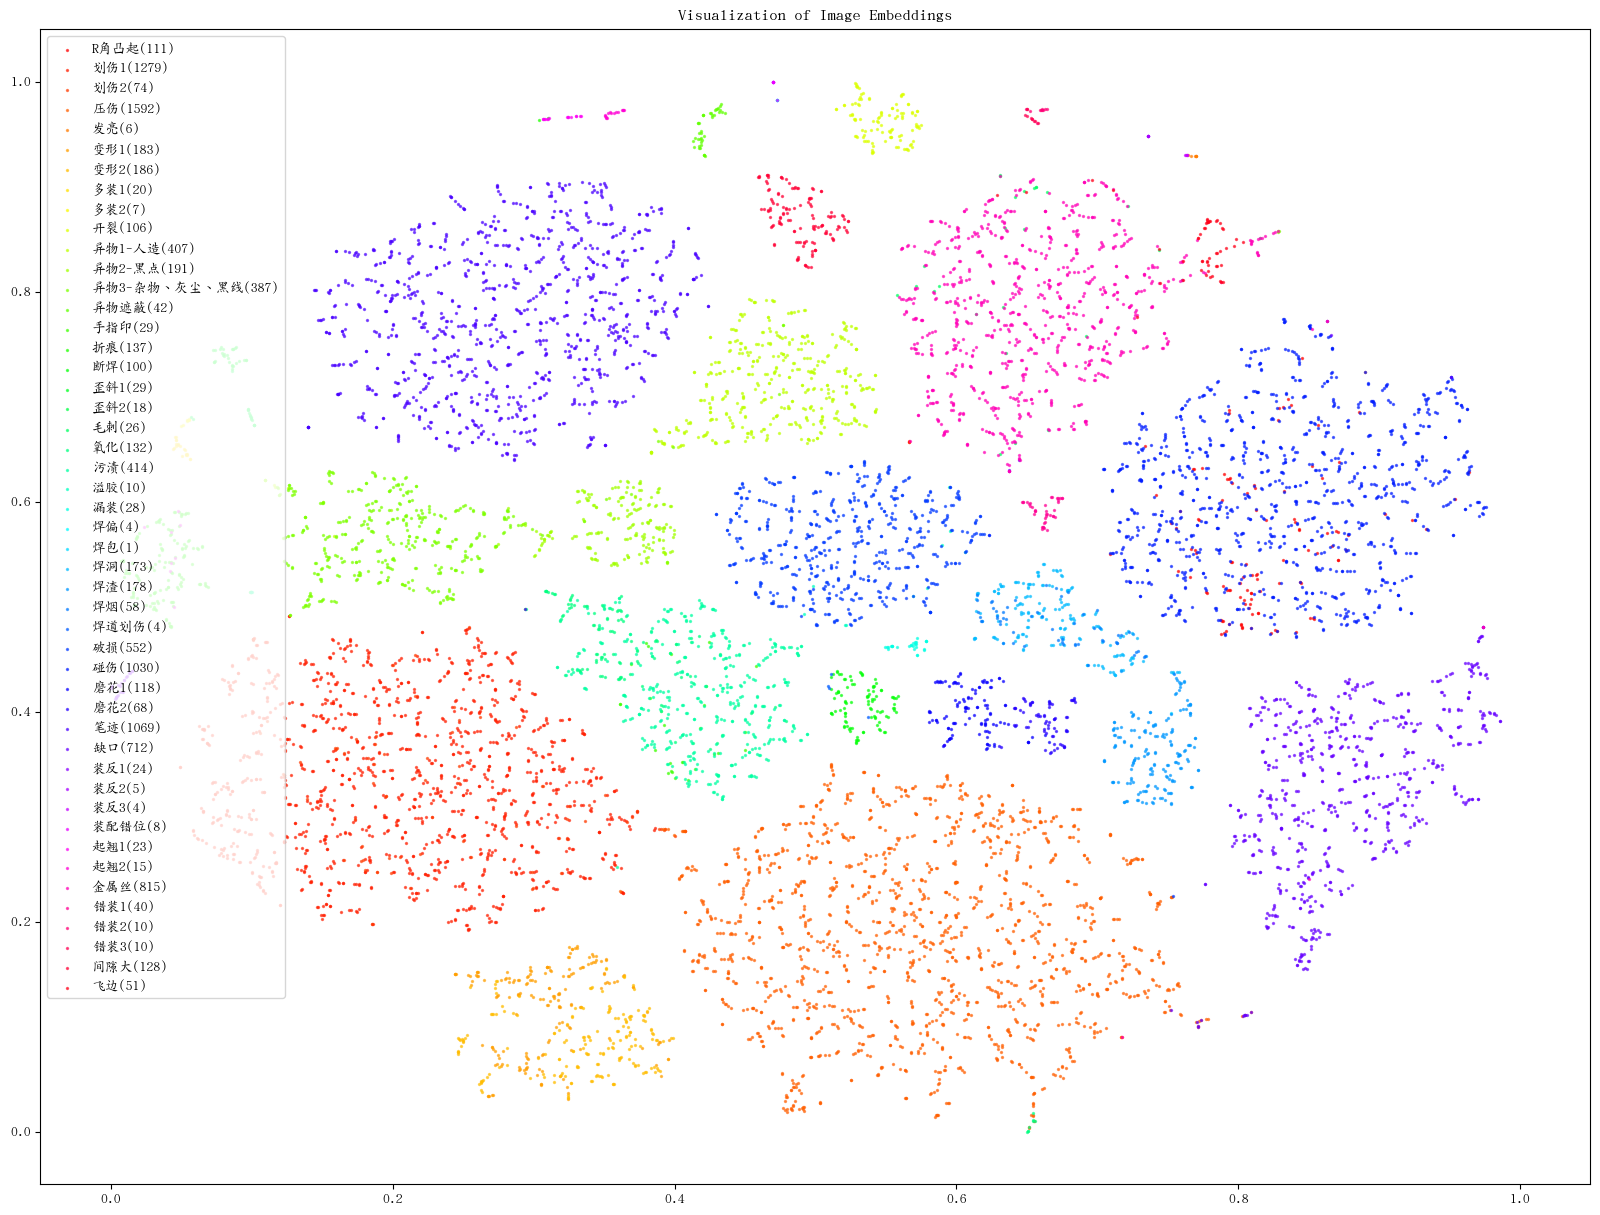

In [16]:
reducer = TSNE(
    n_components=2,
    perplexity=5,
    metric='cosine',
    random_state=42,
)
# reducer = umap.UMAP(
#     n_components=2,
#     random_state=42,
#     metric='cosine',
# )

embeddings_2d = reducer.fit_transform(selected_embeddings)
# 先将数据移到原点
embeddings_2d[:, 0] = embeddings_2d[:, 0] - embeddings_2d[:, 0].min()
embeddings_2d[:, 1] = embeddings_2d[:, 1] - embeddings_2d[:, 1].min()

# 找到最大的范围作为缩放基准
range_x = embeddings_2d[:, 0].max()
range_y = embeddings_2d[:, 1].max()
max_range = max(range_x, range_y)

# 按照最大范围等比例缩放到 [0, 1]
if max_range > 0:
    embeddings_2d = embeddings_2d / max_range

# 可视化embeddings
unique_selected_labels = list(set(selected_labels))
unique_selected_labels.sort()
print(f"Total unique labels: {len(unique_selected_labels)}")

# 使用更大的色彩映射或生成随机颜色
if len(unique_selected_labels) <= 10:
    colors = plt.cm.tab10(np.linspace(0, 1, len(unique_selected_labels)))
else:
    # 方案1: 使用hsv色彩空间生成足够多的颜色
    colors = plt.cm.hsv(np.linspace(0, 1, len(unique_selected_labels)))

label_to_color = dict(zip(unique_selected_labels, colors))

plt.figure(figsize=(20, 15))
for label in unique_selected_labels:
    mask = np.array([l == label for l in selected_labels])
    plt.scatter(
        embeddings_2d[mask, 0], 
        embeddings_2d[mask, 1],
        c=[label_to_color[label]],
        label=label + "({})".format(np.sum(mask)),
        alpha=0.6,
        s=2
    )

plt.legend()
plt.title("Visualization of Image Embeddings")
plt.xlim(-0.05, 1.05)
plt.ylim(-0.05, 1.05)
plt.show()

---

```python
label_2_embeddings = {}
for emb, lb in zip(embeddings, labels):
    if lb not in label_2_embeddings:
        label_2_embeddings[lb] = []
    label_2_embeddings[lb].append(emb)

filter_embeddings = {}
for lb in label_2_embeddings:
    if len(label_2_embeddings[lb]) >= 500:
        filter_embeddings[lb] = np.stack(label_2_embeddings[lb])

for lb in filter_embeddings:
    print(f"Label: {lb}, Num embeddings: {filter_embeddings[lb].shape[0]}")
```